IMPORT LIBRARIES

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

DATA LOADING AND INITIAL EXPLORATION


In [36]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/autompg-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'autompg-dataset' dataset.
Path to dataset files: /kaggle/input/autompg-dataset


In [37]:
df = pd.read_csv(f'{path}/auto-mpg.csv')
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [38]:
df.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model year', 'origin', 'car name'],
      dtype='object')

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


In [40]:
df.isna().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model year,0
origin,0
car name,0


DATA PREPROCESSING AND CLEANING

In [41]:
# Handling the missing values (replace '? with NaN)
df = df.replace('?',np.nan)
df.isna().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,6
weight,0
acceleration,0
model year,0
origin,0
car name,0


In [42]:
#convert numeric col to float
numeric_cols = ['mpg','horsepower', 'weight','acceleration']
df[numeric_cols]=df[numeric_cols].astype(float)
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(5), int64(3), object(1)
memory usage: 28.1+ KB


In [43]:
#Drop rows with missing numeric values
df = df.dropna(subset=numeric_cols)
df.isna().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model year,0
origin,0
car name,0


In [44]:
#Clean the column name
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
df.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model_year', 'origin', 'car_name'],
      dtype='object')

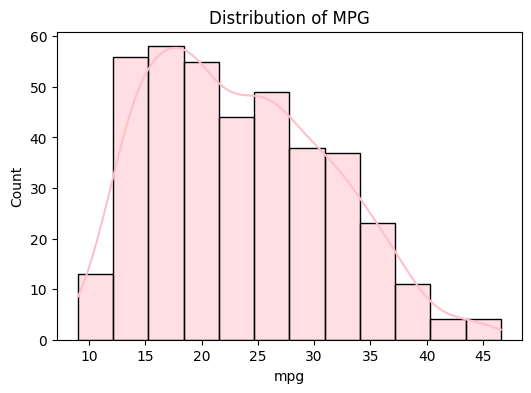

In [45]:
plt.figure(figsize=(6,4))
sns.histplot(df['mpg'],kde = True,edgecolor = 'black',color = 'pink')
plt.title('Distribution of MPG')
plt.show()

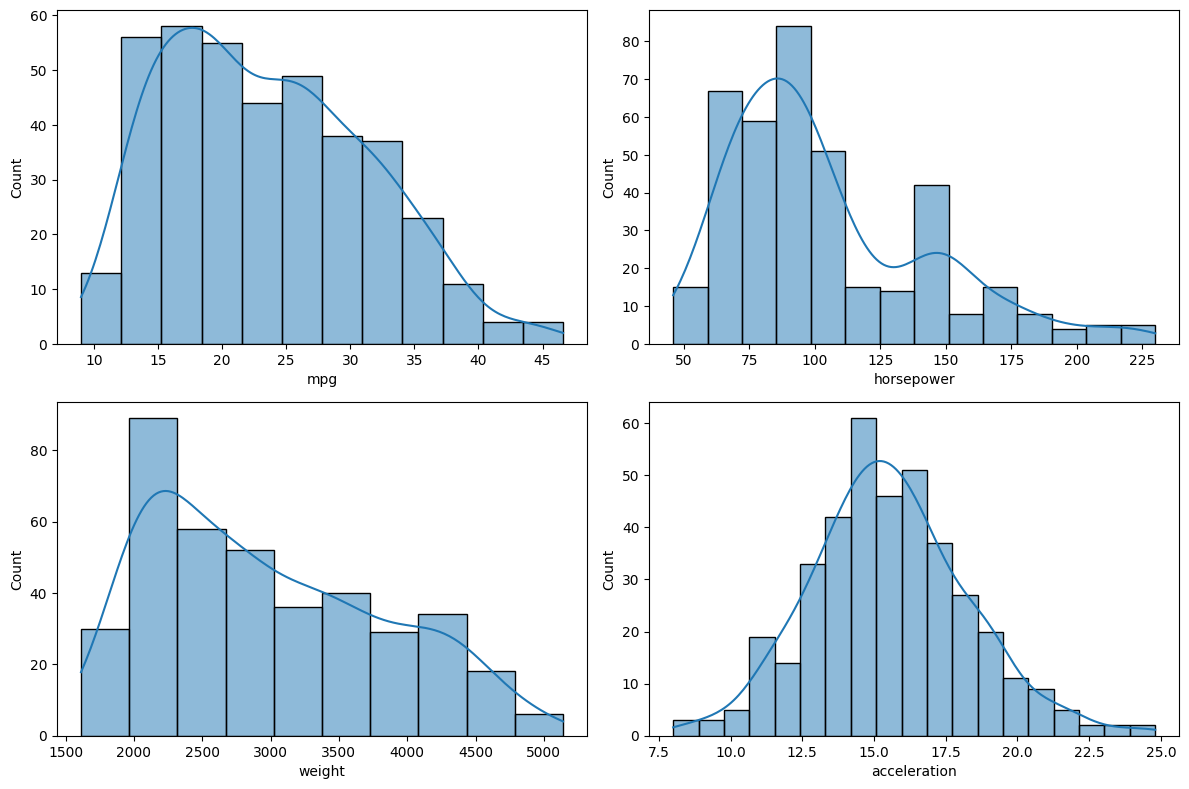

In [46]:
fig, ax = plt.subplots(2,2, figsize=(12,8))
sns.histplot(df['mpg'], kde=True, ax=ax[0][0])
sns.histplot(df['horsepower'], kde=True, ax=ax[0][1])
sns.histplot(df['weight'], kde=True, ax=ax[1][0])
sns.histplot(df['acceleration'], kde=True, ax=ax[1][1])
plt.tight_layout()


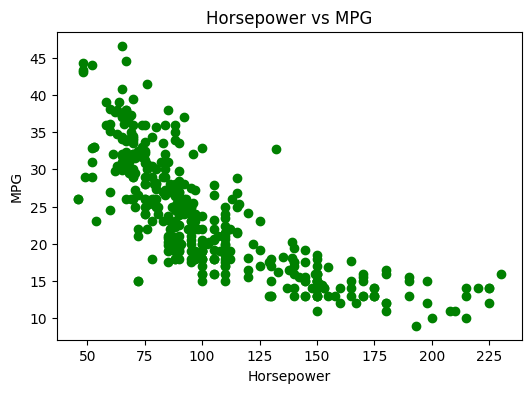

In [47]:
plt.figure(figsize=(6,4))
plt.scatter(df['horsepower'],df['mpg'],color = 'green')
plt.title('Horsepower vs MPG')
plt.xlabel('Horsepower')
plt.ylabel('MPG')
plt.show()

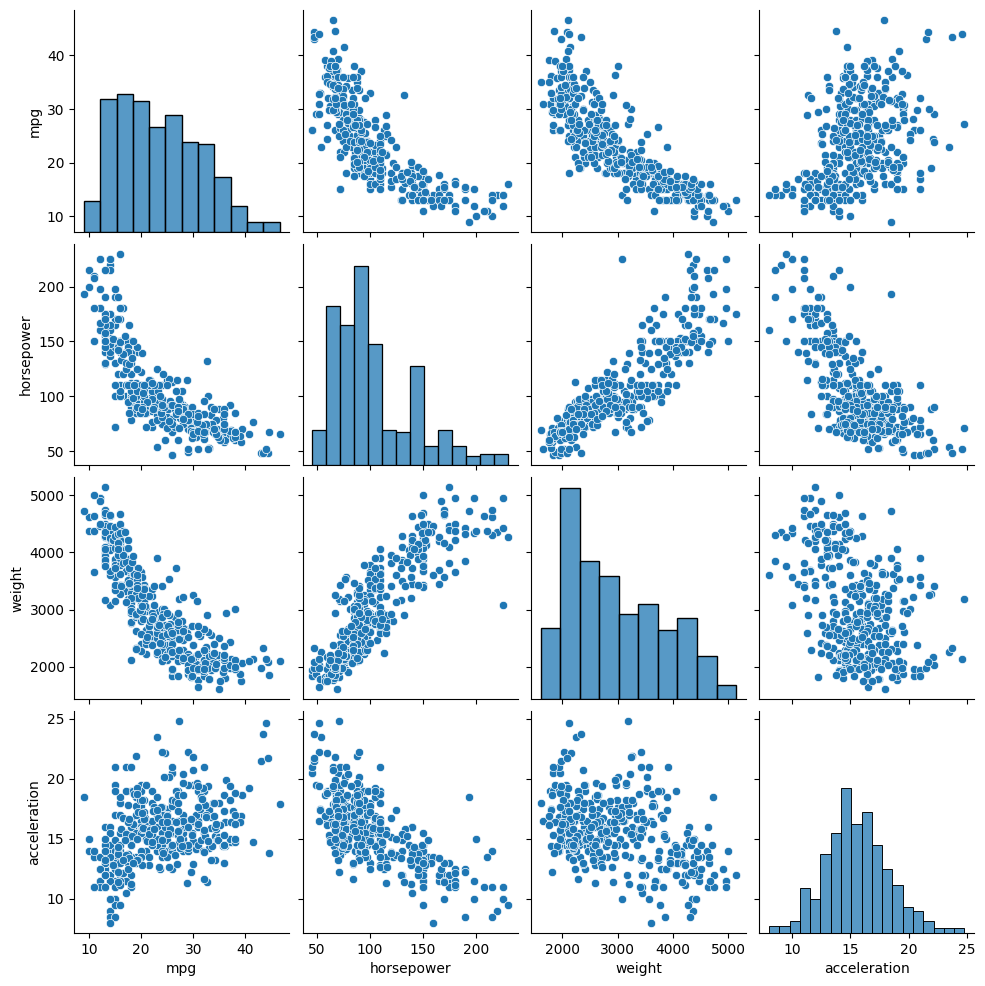

In [48]:
sns.pairplot(df[['mpg','horsepower', 'weight','acceleration']])
plt.show()

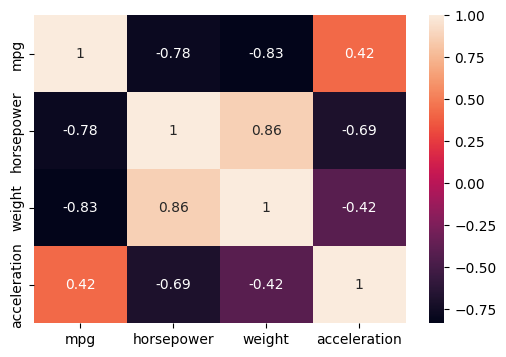

In [49]:

plt.figure(figsize=(6,4))
sns.heatmap(df[['mpg','horsepower', 'weight','acceleration']].corr(),annot=True)
plt.show()

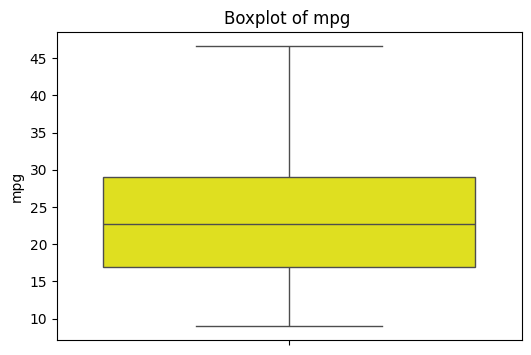

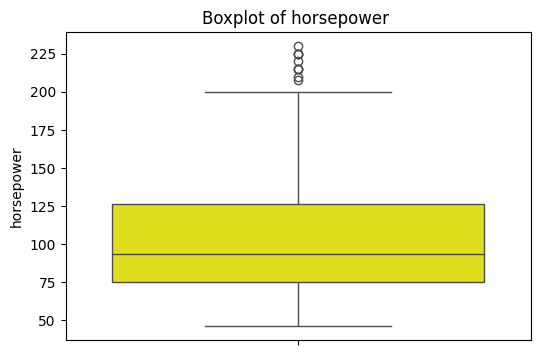

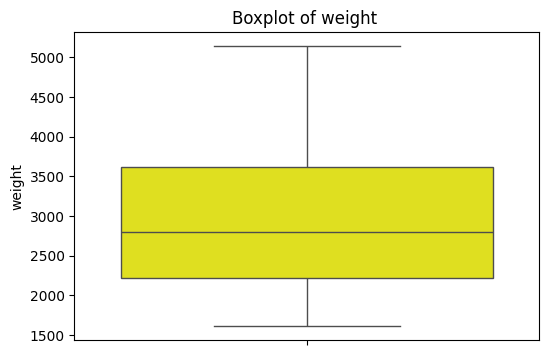

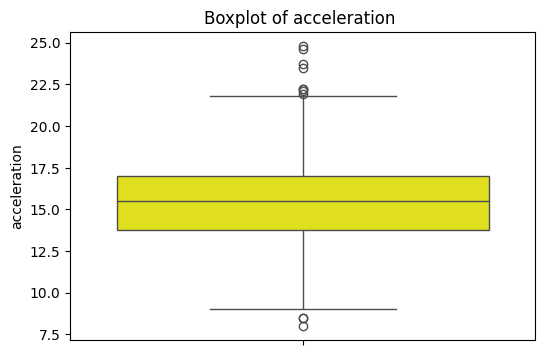

In [50]:
#Check the outliers for all columns
for i in numeric_cols:
    plt.figure(figsize=(6,4))
    plt.title(f'Boxplot of {i} ')
    sns.boxplot(df[i],color = 'yellow')
    plt.show()

In [51]:
#Remove outliers using IQR
Q1 = df['horsepower'].quantile(0.25)
Q3 = df['horsepower'].quantile(0.75)

IQR = Q3-Q1

lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")

Lower Bound: -1.5, Upper Bound: 202.5


In [52]:
df.drop_duplicates(inplace = True)

In [53]:
#Clipping the outliers
df_cleaned = df[(df['horsepower']>=lower_bound)&(df['horsepower']<=upper_bound)]

In [54]:
df.shape

(392, 9)

In [55]:
df_cleaned.shape

(382, 9)

In [56]:
# Regression BEFORE outlier removal

# Select features for modeling
features = ["horsepower",'acceleration','weight']

x = df[features]
y = df["mpg"]

print(f"Features selected: {features}")
print(f"Target variable: MPG")
print(f"Feature matrix shape: {x.shape}")
print(f"Target vector shape: {y.shape}")

# Check feature distributions
print("\nFeature Statistics:")
print(x.describe())


Features selected: ['horsepower', 'acceleration', 'weight']
Target variable: MPG
Feature matrix shape: (392, 3)
Target vector shape: (392,)

Feature Statistics:
       horsepower  acceleration       weight
count  392.000000    392.000000   392.000000
mean   104.469388     15.541327  2977.584184
std     38.491160      2.758864   849.402560
min     46.000000      8.000000  1613.000000
25%     75.000000     13.775000  2225.250000
50%     93.500000     15.500000  2803.500000
75%    126.000000     17.025000  3614.750000
max    230.000000     24.800000  5140.000000


In [57]:
#Split the data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [58]:
# Initialize models
mode_before = LinearRegression()

# Train model
mode_before.fit(x_train,y_train)

# Make predictions
pred_before = mode_before.predict(x_test)

# Calculate metrics
print(f"MSE: {mean_squared_error(y_test,pred_before):.2f}")
print(f"R2: {r2_score(y_test,pred_before):.2f}")

MSE: 17.81
R2: 0.65


In [60]:
# Regression AFTER outlier removal

# Select features for modeling
features = ["horsepower",'acceleration','weight']

X = df_cleaned[features]
y = df_cleaned["mpg"]

print(f"Features selected: {features}")
print(f"Target variable: MPG")
print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

# Check feature distributions
print("\nFeature Statistics:")
print(X.describe())

Features selected: ['horsepower', 'acceleration', 'weight']
Target variable: MPG
Feature matrix shape: (382, 3)
Target vector shape: (382,)

Feature Statistics:
       horsepower  acceleration       weight
count  382.000000    382.000000   382.000000
mean   101.476440     15.666754  2940.947644
std     34.163314      2.667648   825.667561
min     46.000000      8.000000  1613.000000
25%     75.000000     14.000000  2220.000000
50%     92.000000     15.500000  2764.500000
75%    119.000000     17.200000  3533.750000
max    200.000000     24.800000  5140.000000


In [63]:
#Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [64]:
# Initialize models
mode_after = LinearRegression()

# Train model
mode_after.fit(X_train,y_train)

# Make predictions
pred_after = mode_after.predict(X_test)

# Calculate metrics
print(f"MSE: {mean_squared_error(y_test,pred_after):.2f}")
print(f"R2: {r2_score(y_test,pred_after):.2f}")

MSE: 18.40
R2: 0.70


In [61]:
#Regression AFTER outlier removal

x2 = df_cleaned[["horsepower"]]
y2 = df_cleaned["mpg"]

x2_train, x2_test, y2_train, y2_test = train_test_split(x2, y2, test_size=0.2, random_state=42)

model_after = LinearRegression()
model_after.fit(x2_train,y2_train)
pred_after = model_after.predict(x2_test)

print(f"MSE: {mean_squared_error(y2_test,pred_after)}")
print(f"R2: {r2_score(y2_test,pred_after)}")

MSE: 18.55780100636605
R2: 0.6994698685241629


In [ ]:
# See the two Regression lines

plt.plot(df['horsepower'],mode_before.predict(x),label='Before Outlier Removal')
plt.plot(df_cleaned['horsepower'],model_after.predict(x2),label='After Outlier Removal')
plt.legend()
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(alpha=0.01),
    "Random Forest": RandomForestRegressor(n_estimators=200)
}


Text(0.5, 1.0, 'Actual vs Predicted')

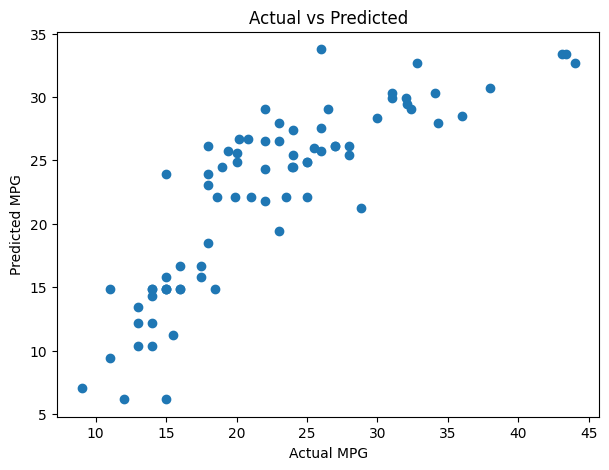

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(y2_test, pred_after)
plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title("Actual vs Predicted")

Text(0.5, 1.0, 'Residual Plot')

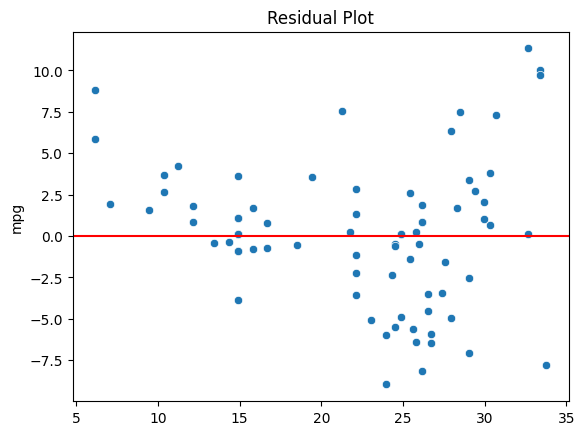

In [ ]:
residuals = y2_test - pred_after
sns.scatterplot(x=pred_after, y=residuals)
plt.axhline(0, color='red')
plt.title("Residual Plot")

In [67]:
# Importing the pickle file
import pickle

#dump the pickle file
with open("LinearRegression.pkl","wb") as f:
  pickle.dump(mode_after,f)